# PROJECT 1

## importing Libraies

In [30]:
import geopandas as gpd
import rasterio
from rasterio.plot import show
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

## Loading data

In [31]:
shp_path = "/home/gib/rwanda-lulc-project/data/train_val.shp"

points = gpd.read_file(shp_path)

raster_path = "/home/gib/rwanda-lulc-project/data/S2_srw.tif"


## Exploratory data Analysis

### shape file

In [32]:
print(points.shape)
print(points.columns)
print(points.crs)
points.head()

(800, 2)
Index(['category', 'geometry'], dtype='str')
EPSG:4326


,category,geometry
0,forest,POINT (29.05868 -2.42512)
1,tea,POINT (29.06158 -2.42884)
2,tea,POINT (29.06205 -2.42944)
3,tea,POINT (29.06232 -2.43084)
4,tea,POINT (29.06508 -2.43202)


In [33]:
points['category'].value_counts()

category
forest    200
tea       200
other     200
water     200
Name: count, dtype: int64

### Raster

In [34]:
with rasterio.open(raster_path) as src:
    print("CRS:", src.crs)
    print("Width, Height:", src.width, src.height)
    print("Number of bands:", src.count)
    print("Bounds:", src.bounds)
    print("Dtype:", src.dtypes)

CRS: EPSG:4326
Width, Height: 654 881
Number of bands: 11
Bounds: BoundingBox(left=29.026632955055213, bottom=-2.476116249147049, right=29.08538277463663, top=-2.396974672616119)
Dtype: ('float64', 'float64', 'float64', 'float64', 'float64', 'float64', 'float64', 'float64', 'float64', 'float64', 'float64')


### Checking Band 

In [35]:
with rasterio.open(raster_path) as src:
    print(src.descriptions)
    print(src.tags())
    for i in range(1, src.count + 1):
        print(i, src.tags(i))

('B12', 'B11', 'B10', 'B9', 'B8', 'B7', 'B6', 'B5', 'B4', 'B3', 'B2')
{'AREA_OR_POINT': 'Area'}
1 {'STATISTICS_APPROXIMATE': 'YES', 'STATISTICS_MAXIMUM': '0.4921', 'STATISTICS_MEAN': '0.17514731878345', 'STATISTICS_MINIMUM': '0.1043', 'STATISTICS_STDDEV': '0.035275422691041', 'STATISTICS_VALID_PERCENT': '100'}
2 {'STATISTICS_APPROXIMATE': 'YES', 'STATISTICS_MAXIMUM': '0.5133', 'STATISTICS_MEAN': '0.24707601419152', 'STATISTICS_MINIMUM': '0.1097', 'STATISTICS_STDDEV': '0.053792085138153', 'STATISTICS_VALID_PERCENT': '100'}
3 {'STATISTICS_APPROXIMATE': 'YES', 'STATISTICS_MAXIMUM': '0.1038', 'STATISTICS_MEAN': '0.1011131325258', 'STATISTICS_MINIMUM': '0.1007', 'STATISTICS_STDDEV': '0.00028196345452965', 'STATISTICS_VALID_PERCENT': '100'}
4 {'STATISTICS_APPROXIMATE': 'YES', 'STATISTICS_MAXIMUM': '0.2395', 'STATISTICS_MEAN': '0.17417092591265', 'STATISTICS_MINIMUM': '0.1111', 'STATISTICS_STDDEV': '0.024608271624828', 'STATISTICS_VALID_PERCENT': '100'}
5 {'STATISTICS_APPROXIMATE': 'YES', 'ST

## Extracting band values at each training point

In [36]:
band_names = ['B12', 'B11', 'B10', 'B9', 'B8', 'B7', 'B6', 'B5', 'B4', 'B3', 'B2']

coords = [(geom.x, geom.y) for geom in points.geometry]

with rasterio.open(raster_path) as src:
    sampled = list(src.sample(coords))

sampled_array = np.array(sampled)  # shape: (800, 11)

samples_df = pd.DataFrame(sampled_array, columns=band_names)
samples_df['category'] = points['category'].values

samples_df.head(5)

,B12,B11,B10,B9,B8,B7,B6,B5,B4,B3,B2,category
0,0.1601,0.2375,0.1011,0.1641,0.3235,0.3295,0.2809,0.1820,0.1574,0.1754,0.1921,forest
1,0.1669,0.2689,0.1011,0.1912,0.4362,0.4444,0.3682,0.2084,0.1557,0.1918,0.1945,tea
2,0.1992,0.2977,0.1011,0.1783,0.3951,0.4032,0.3442,0.1986,0.1654,0.1853,0.1955,tea
3,0.1590,0.2605,0.1011,0.2002,0.4599,0.4679,0.3836,0.2054,0.1556,0.1934,0.1932,tea
4,0.1599,0.2598,0.1011,0.1958,0.4520,0.4589,0.3820,0.2033,0.1546,0.1904,0.1938,tea


### Checking missing and not required values

In [37]:
print(samples_df.isnull().sum())
print(samples_df.shape)
samples_df['category'].value_counts()

B12         0
B11         0
B10         0
B9          0
B8          0
B7          0
B6          0
B5          0
B4          0
B3          0
B2          0
category    0
dtype: int64
(800, 12)


category
forest    200
tea       200
other     200
water     200
Name: count, dtype: int64

## Adding spectral indices

In [38]:
# Normalized Difference Vegetation Index 
samples_df['NDVI'] = (samples_df['B8'] - samples_df['B4']) / (samples_df['B8'] + samples_df['B4'])

# Normalized Difference Water Index 
samples_df['NDWI'] = (samples_df['B3'] - samples_df['B8']) / (samples_df['B3'] + samples_df['B8'])

#Normalized Difference Moisture Index 
samples_df['NDMI'] = (samples_df['B8'] - samples_df['B11']) / (samples_df['B8'] + samples_df['B11'])

samples_df.head()

,B12,B11,B10,B9,B8,B7,B6,B5,B4,B3,B2,category,NDVI,NDWI,NDMI
0,0.1601,0.2375,0.1011,0.1641,0.3235,0.3295,0.2809,0.1820,0.1574,0.1754,0.1921,forest,0.345394,-0.296853,0.153298
1,0.1669,0.2689,0.1011,0.1912,0.4362,0.4444,0.3682,0.2084,0.1557,0.1918,0.1945,tea,0.473898,-0.389172,0.237271
2,0.1992,0.2977,0.1011,0.1783,0.3951,0.4032,0.3442,0.1986,0.1654,0.1853,0.1955,tea,0.409813,-0.361475,0.140589
3,0.1590,0.2605,0.1011,0.2002,0.4599,0.4679,0.3836,0.2054,0.1556,0.1934,0.1932,tea,0.494395,-0.407929,0.276791
4,0.1599,0.2598,0.1011,0.1958,0.4520,0.4589,0.3820,0.2033,0.1546,0.1904,0.1938,tea,0.490274,-0.407223,0.270020


### feature separability

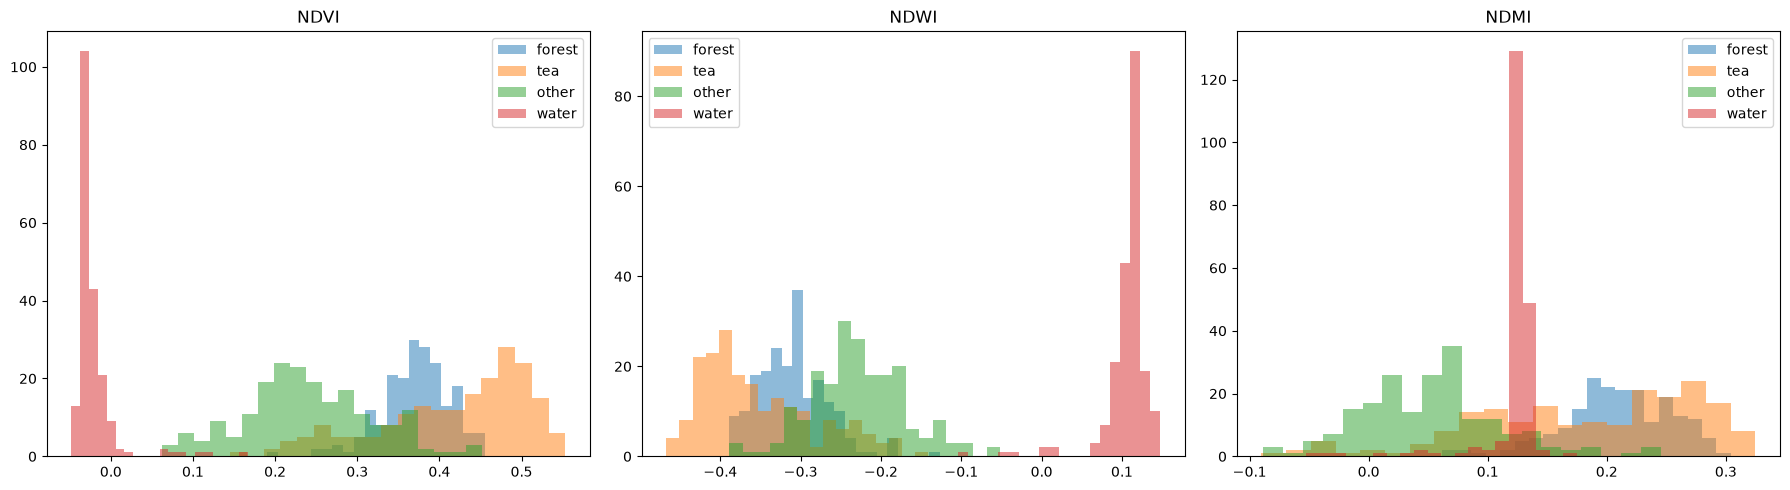

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, ['NDVI', 'NDWI', 'NDMI']):
    for cat in samples_df['category'].unique():
        subset = samples_df[samples_df['category'] == cat]
        ax.hist(subset[feature], bins=20, alpha=0.5, label=cat)
    ax.set_title(feature)
    ax.legend()

plt.tight_layout()
plt.show()

## features and target

In [40]:
feature_cols = ['B12', 'B11', 'B10', 'B9', 'B8', 'B7', 'B6', 'B5', 'B4', 'B3', 'B2', 'NDVI', 'NDWI', 'NDMI']

X = samples_df[feature_cols]
y = samples_df['category']

print(X.shape, y.shape)
X.head()

(800, 14) (800,)


,B12,B11,B10,B9,B8,B7,B6,B5,B4,B3,B2,NDVI,NDWI,NDMI
0,0.1601,0.2375,0.1011,0.1641,0.3235,0.3295,0.2809,0.1820,0.1574,0.1754,0.1921,0.345394,-0.296853,0.153298
1,0.1669,0.2689,0.1011,0.1912,0.4362,0.4444,0.3682,0.2084,0.1557,0.1918,0.1945,0.473898,-0.389172,0.237271
2,0.1992,0.2977,0.1011,0.1783,0.3951,0.4032,0.3442,0.1986,0.1654,0.1853,0.1955,0.409813,-0.361475,0.140589
3,0.1590,0.2605,0.1011,0.2002,0.4599,0.4679,0.3836,0.2054,0.1556,0.1934,0.1932,0.494395,-0.407929,0.276791
4,0.1599,0.2598,0.1011,0.1958,0.4520,0.4589,0.3820,0.2033,0.1546,0.1904,0.1938,0.490274,-0.407223,0.270020


## Splittind data for training and validating 

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # to ensure that each class is proportionally represented in both sets
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print(y_train.value_counts())
print(y_val.value_counts())

Train shape: (640, 14)
Validation shape: (160, 14)
category
forest    160
other     160
tea       160
water     160
Name: count, dtype: int64
category
tea       40
other     40
water     40
forest    40
Name: count, dtype: int64


### Cross validation 
i want to know if model will generalize

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='accuracy')

print("CV accuracy scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean().round(4))
print("Std CV accuracy:", cv_scores.std().round(4))

CV accuracy scores: [0.8828125 0.890625  0.96875   0.9375    0.90625  ]
Mean CV accuracy: 0.9172
Std CV accuracy: 0.0319


## fit the final model on the full training set

In [43]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

## Evaluating the model

In [44]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = rf.predict(X_val)

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

      forest       0.97      0.90      0.94        40
       other       0.76      0.95      0.84        40
         tea       0.94      0.78      0.85        40
       water       1.00      1.00      1.00        40

    accuracy                           0.91       160
   macro avg       0.92      0.91      0.91       160
weighted avg       0.92      0.91      0.91       160



### Normalizing the Confusion matrix

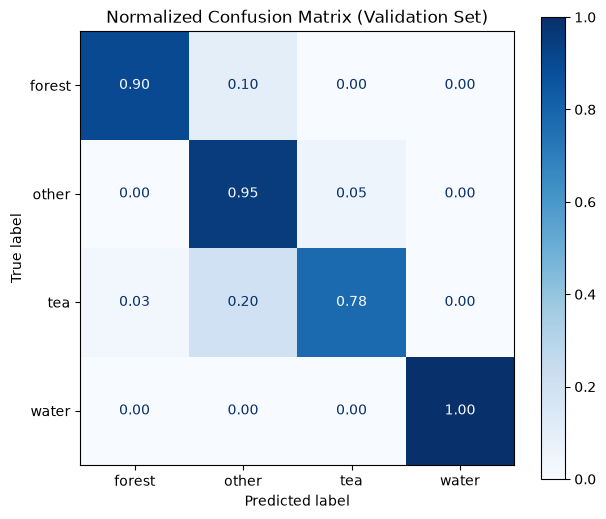

In [45]:
labels = sorted(y_val.unique())

cm = confusion_matrix(y_val, y_pred, labels=labels, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', values_format='.2f')
plt.title("Normalized Confusion Matrix (Validation Set)")
plt.show()

# Predict land use across the entire area of interest

### Reading the full raster and computing indices per-pixel

In [46]:
with rasterio.open(raster_path) as src:
    img = src.read()   
    profile = src.profile  # metadata for writing output later

# img indices
B12, B11, B10, B9, B8, B7, B6, B5, B4, B3, B2 = img

# Avoid divide by zero issues
np.seterr(divide='ignore', invalid='ignore')

NDVI = (B8 - B4) / (B8 + B4)
NDWI = (B3 - B8) / (B3 + B8)
NDMI = (B8 - B11) / (B8 + B11)

print(img.shape, NDVI.shape)

(11, 881, 654) (881, 654)


### Reshaping into a a table

In [47]:
# Stack all bands and  indices in the SAME order as feature_cols
stacked = np.stack([B12, B11, B10, B9, B8, B7, B6, B5, B4, B3, B2, NDVI, NDWI, NDMI], axis=-1)
# shape: (height, width, 14)
h, w, n_features = stacked.shape
flat_pixels = stacked.reshape(-1, n_features)  # shape: (height*width, 14)

flat_df = pd.DataFrame(flat_pixels, columns=feature_cols)
print(flat_df.shape)
flat_df.isnull().sum()

(576174, 14)


B12     0
B11     0
B10     0
B9      0
B8      0
B7      0
B6      0
B5      0
B4      0
B3      0
B2      0
NDVI    0
NDWI    0
NDMI    0
dtype: int64

## pridicting 

In [48]:
# Predict on all pixels
flat_preds = rf.predict(flat_df)

# Reshape predictions back into image shape
pred_map = flat_preds.reshape(h, w)

print(pred_map.shape)
print(np.unique(pred_map, return_counts=True))

(881, 654)
(array(['forest', 'other', 'tea', 'water'], dtype=object), array([211416, 208365, 135506,  20887]))


### Visualizing the predicted land use map

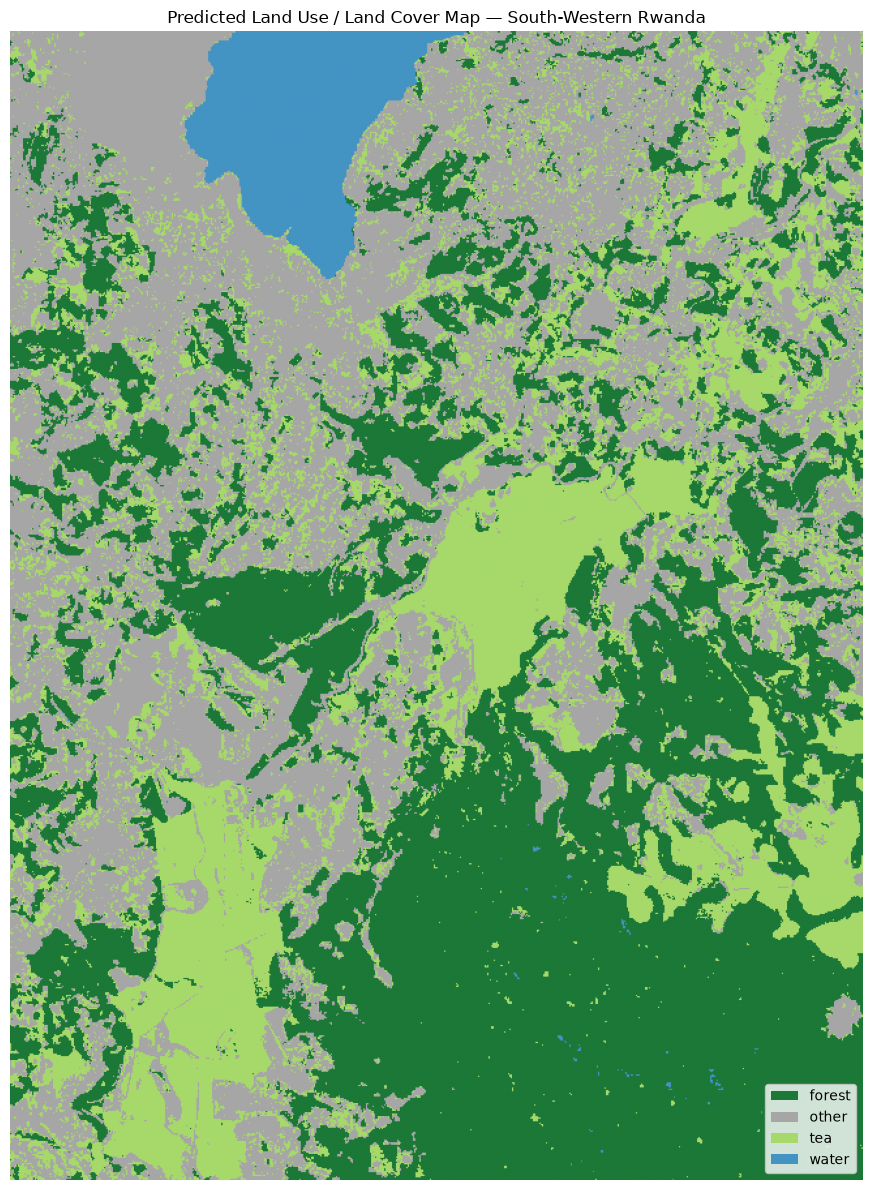

In [49]:
# Map class labels to numeric codes for plotting
class_list = sorted(np.unique(pred_map))  # ['forest', 'other', 'tea', 'water']
class_to_num = {c: i for i, c in enumerate(class_list)}
num_map = np.vectorize(class_to_num.get)(pred_map)

# Define colors for each class
colors = ('#1b7837', '#a6a6a6', '#a6d96a', '#4393c3')  # forest=dark green, other=grey, tea=light green, water=blue
from matplotlib.colors import ListedColormap
cmap = ListedColormap(colors)

fig, ax = plt.subplots(figsize=(10, 12))
im = ax.imshow(num_map, cmap=cmap)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], label=class_list[i]) for i in range(len(class_list))]
ax.legend(handles=legend_elements, loc='lower right')

ax.set_title("Predicted Land Use / Land Cover Map — South-Western Rwanda")
ax.axis('off')
plt.tight_layout()
plt.show()

## Saving the map GeoTIFF

In [50]:
import os
os.makedirs("/home/gib/rwanda-lulc-project/outputs", exist_ok=True)

In [51]:
# Map class labels to integer codes for saving (rasters need numeric)
class_list = sorted(np.unique(pred_map))
class_to_num = {c: i for i, c in enumerate(class_list)}
num_map = np.vectorize(class_to_num.get)(pred_map).astype('uint8')

# Update the profile for a single-band, byte-type output
out_profile = profile.copy()
out_profile.update(dtype='uint8', count=1, nodata=None)

output_path = "/home/gib/rwanda-lulc-project/outputs/predicted_lulc.tif"

with rasterio.open(output_path, 'w', **out_profile) as dst:
    dst.write(num_map, 1)
    # Save a mapping of code 
    dst.update_tags(**{str(v): k for k, v in class_to_num.items()})

print("Saved to:", output_path)
print("Class code mapping:", class_to_num)

Saved to: /home/gib/rwanda-lulc-project/outputs/predicted_lulc.tif
Class code mapping: {'forest': 0, 'other': 1, 'tea': 2, 'water': 3}


# PROJECT 2

## Setup

A PostgreSQL server (v14) was installed locally, and the provided SQL dump
(`postgresql_18.sql`) was restored into a new database named `parch_posey`,
containing the following tables: `accounts`, `orders`, `region`, `sales_reps`,
`web_events`.

Queries were written and executed using **DBeaver** (a SQL client/IDE), connected
to the local PostgreSQL instance. Each query's result set was exported directly
from DBeaver as a CSV file, saved in the `project2_csv_output/` folder alongside
this notebook.

The SQL used for each query is documented below for reference and reproducibility.

### Query 1: Total number of rows in the `accounts` table

```sql
SELECT COUNT(*) AS total_rows
FROM accounts;
```
### Query 2: Total dollar amount of sales in the `orders` table

```sql
SELECT SUM(total_amt_usd) AS total_sales_usd
FROM orders;
```
### Query 3: Earliest order date

```sql
SELECT MIN(occurred_at) AS earliest_order_date
FROM orders;
```
### Query 4: Account name and order dates


```sql
SELECT a.name AS account_name, o.occurred_at AS order_date
FROM accounts a
JOIN orders o ON a.id = o.account_id
ORDER BY a.name, o.occurred_at;
```
